In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/home/xiaowenz/finetune')

In [6]:
from PIL import Image
from pathlib import Path
import datasets

def convert_to_swift_format(conversation, media_dir):
  """
  Convert a conversation from the current format to Swift format.

  Args:
      conversation: List of message dictionaries in the format:
          [{'role': 'system', 'content': '...'},
           {'role': 'user', 'content': [{'video': 'path/to/video.mp4'}]},
           {'role': 'user', 'content': 'Question text'},
           {'role': 'assistant', 'content': 'Answer tdext'}]

  Returns:
      Dictionary in Swift format with 'messages' key and optional media keys
  """
  result = {"messages": []}
  images = []
  videos = []
  audios = []
  # Track media placeholders for content substitution
  image_count = 0
  video_count = 0
  audio_count = 0
  for message in conversation:
    role = message['role']
    content = message['content']

    # Process content based on its type
    if isinstance(content, str):
      # Simple text content
      messages = result['messages']
      if messages and messages[-1]['role'] == role:
        messages[-1]['content'] += '\n' + content
      else:
        result["messages"].append({
            "role": role,
            "content": content
        })
    elif isinstance(content, list):
      # Content with potential media
      text_parts = []

      for item in content:
        if isinstance(item, dict):
          if 'text' in item:
            text_parts.append(item['text'])
          elif 'image' in item:
            text_parts.append("<image>")
            img = item['image']
            if isinstance(img, Image.Image):
              # Save the image to the media directory
              image_path = str(media_dir / f"image_{str(image_count).zfill(6)}.jpg")
              img.save(image_path)
              img = image_path
            images.append(img)
            image_count += 1
          elif 'video' in item:
            text_parts.append("<video>")
            videos.append(item['video'])
            video_count += 1
          else:
            raise ValueError(f"Unsupported media type in item: {item}")
        elif isinstance(item, str):
          text_parts.append(item)

      # Join all text parts
      content_text = ''.join(text_parts)
      messages = result['messages']
      if messages and messages[-1]['role'] == role:
        messages[-1]['content'] += '\n' + content_text
      else:
        result["messages"].append({
            "role": role,
            "content": content_text
        })

  # Add media arrays if they exist
  if images:
    result["images"] = images
  if videos:
    result["videos"] = videos
  if audios:
    result["audios"] = audios
  return result


In [3]:
from transformers import AutoProcessor
from qwenvl.argument import ProcessingArguments
from qwenvl.data import avail_datasets
from qwenvl.data.conversation import *
from qwenvl.data.preprocess import VerifyMediaStrategy, GetNumMediaTokensStrategy, GetNumTokensStrategy
from qwenvl.data.prompts import SYS_PROMPTS, USR_PROMPTS
from qwenvl.utils import get_logger
import datasets
logger = get_logger(__name__)

processor = AutoProcessor.from_pretrained(
  "Qwen/Qwen2.5-VL-3B-Instruct", use_fast=True)

proc_args = ProcessingArguments(
    image_min_pixels=processor.image_processor.min_pixels,
    image_max_pixels=processor.image_processor.max_pixels,
    video_min_pixels=processor.video_processor.min_pixels,
    video_max_pixels=processor.video_processor.max_pixels,
    resize_img=False,
    resize_vid=False,
    base_interval=1,
)

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


In [7]:
del avail_datasets
import tqdm
from qwenvl.data import avail_datasets
from qwenvl.data.conversation import *

surgeryvid = '''You are a surgical analyst and trainee observing an educational demonstration of a real procedure.

**Objective:** Interpret the video with the dual goal of:
1. Accurately describing what occurs in the surgical field.
2. Integrating this observation with your knowledge of anatomy, physiology, and surgical technique.

---

**Positive Instructions — How to Analyze and Learn:**

1. **Spatial focus:** Direct attention to the critical zone — where the active tip of the surgical instrument interacts with the target anatomical structure. Ignore background features unless they directly influence the procedure.

2. **Temporal focus:** Identify short sequences that capture key procedural transitions (before → during → after). These moments are more important than static frames.

3. **Learning mindset:** Treat each observation as an opportunity to reinforce procedural knowledge. Recall relevant anatomy, possible risks, and the intended surgical outcome. Relate visual evidence to known procedural steps (e.g., exposure, resection, anastomosis, closure).

4. **Reasoning process:**
   - **Observe** — Locate the surgical action in space and time.
   - **Recall** — Retrieve relevant medical and procedural knowledge.
   - **Interpret** — Explain the action's purpose and potential implications.
   - **Conclude** — Provide an answer grounded in both the observed evidence and surgical reasoning.

5. **Teaching orientation:** Formulate explanations as if teaching another trainee — precise, structured, and grounded in evidence.

---

**Negative Instructions — What to Avoid:**
- Do not base conclusions on irrelevant visual details such as background staff movement, non-procedural objects, or camera artifacts unless they directly affect the surgical action.
- Do not describe unrelated anatomical regions that are not involved in the current procedural step.
- Do not focus solely on static frames without considering the surrounding context in time.
- Do not ignore your prior medical knowledge — answers should not be purely descriptive without interpretation.
- Do not provide vague statements; always anchor reasoning to specific visual evidence.

---

**Final Guideline:** Always integrate spatial precision, temporal context, and relevant medical knowledge to produce answers that are both visually grounded and educationally valuable.
'''

cp_qa = [
  "The following is a list of question-answer pairs about the surgical video. For each question and its corresponding answer, meticulously identify the specific visual cues, temporal sequences, and spatial details within the video that directly support or explain the provided answer. Your objective is to thoroughly understand how each textual response is grounded in the observed surgical reality, building a comprehensive understanding of the procedure through these targeted queries.",
  "You are tasked with answering a series of questions regarding the surgical procedure shown in the video. For each question in the list, systematically follow these steps to formulate your response: First, Observe the video to pinpoint all relevant visual details. Next, Recall your pertinent medical and anatomical knowledge. Then, Interpret the observed evidence in light of your recalled knowledge. Finally, Conclude with a precise, evidence-based answer that directly addresses the specific question. Proceed through each question, applying this rigorous process."
]

cp_cap = [
  """The following text provides a detailed caption of the surgical procedure presented in the video. Your task is to meticulously cross-reference each statement in the caption with the corresponding visual evidence in the video. For every described action, instrument, or anatomical detail:
*   **Spatially focus** on the precise region where the event occurs and the specific structures involved.
*   **Temporally identify** the exact sequence or key transition in the video that illustrates the described point.
*   **Recall** relevant anatomy, physiology, and surgical principles.
*   **Integrate** this observation with your medical knowledge to solidify your understanding of *why* this action is performed, its immediate impact, and its broader significance within the procedure. Ensure every textual detail is visually validated.""",
  """Your objective is to generate a comprehensive, precise, and educationally valuable caption that synthesizes the surgical demonstration in the video. To achieve this, rigorously employ the following structured reasoning process:
*   **Observe:** Meticulously analyze the video, directing your **spatial attention** to the critical zones of surgical interaction and your **temporal attention** to key procedural transitions (before → during → after).
*   **Recall:** Actively retrieve and apply your human biology, anatomy, and surgical technique knowledge, specifically relevant to the procedure shown.
*   **Interpret:** Explain the purpose, method, and potential implications of each significant action you observe, linking it to known procedural steps (e.g., exposure, resection, anastomosis, closure).
*   **Synthesize:** Combine your observations and interpretations into a concise, structured caption. Emphasize the main procedure, critical actions, involved anatomical structures, and key instruments, formulating your explanation as if teaching another trainee to ensure clarity and accuracy."""
]

ip_cap = [
    'Describe what you observe in the video.',
    'Give a description of the video content.',
    'Summarize the key points of the vision input.',
    'Provide a detailed caption of the video.',
    'What observations do you make about the video?',
    'What are the key points of the video?'
]

def create_swift_ds(ds_name, split, mods, cap_prompts, for_training):
  ds_config = avail_datasets[ds_name]
  ds_config['qa_list_field'] = 'qa_pairs'
  ds = datasets.load_dataset(ds_config['ds_key'], split=split)
  
  # Test set
  def add_qa_pairs(item):
    item['qa_pairs'] = [{'question': item['question'], 'answer': item['answer']}]
    return item
  if 'qa_pairs' not in ds.features:
    ds = ds.map(add_qa_pairs, num_proc=60)
    
  cm = VQACM(**ds_config, for_training=for_training)
  cp = ConversationProcessor(
      cm, mods
  )
  ds = VerifyMediaStrategy(cm.get_content, proc_args)(ds)
  ds = GetNumMediaTokensStrategy(cm.get_content, proc_args)(ds)
  
  images, videos, qa_pairs, lengths, types = [], [], [], [], []
  if 'video' in ds.features:
    for item in tqdm.tqdm(ds):
      qa_pairs.append(item['qa_pairs'])
      videos.append(os.path.join(ds_config['media_dir'], item['video']))
      lengths.append(item['num_media_tokens'] - item['num_media'])
      types.append('qa')
      if 'caption' in item:
        qa_pairs.append([{'question': random.choice(cap_prompts), 'answer': item['caption']}])
        videos.append(os.path.join(ds_config['media_dir'], item['video']))
        lengths.append(item['num_media_tokens'] - item['num_media'])
        types.append('cap')
    ds_dict = {
        'id': list(range(len(qa_pairs))),
        'image': images if images else [[]] * len(qa_pairs),
        'video': videos if videos else [[]] * len(qa_pairs),
        'qa_pairs': qa_pairs,
        'length': lengths,
        'type': types,
    }
    new_ds = datasets.Dataset.from_dict(ds_dict)
  elif 'image' in ds.features:
    def make_new_ds(item):
      item['length'] = item['num_media_tokens'] - item['num_media']
      item['type'] = 'qa'
      return item
    new_ds = ds.add_column('id', list(range(len(ds)))).map(make_new_ds)

  if not for_training:
    ds_dict['label'] = [item['answer'] for item in ds]

  media_dir = Path(ds_config['media_dir'])
    
  def map_for_swift(item) -> dict:
    conv = cp(item)
    n_text_tokens = len(processor.apply_chat_template(conv))
    item['length'] = n_text_tokens + item['length']
    item.update(convert_to_swift_format(conv, media_dir))
    return item

  new_ds = new_ds.map(map_for_swift, num_proc=60, remove_columns=['qa_pairs'])
  new_ds = new_ds.filter(lambda x: x['length'] < 20000)
  return new_ds

contextual_prompt_adder = RolePromptAdder(cp_qa, 1, role='user', skip_type='cap')

train = create_swift_ds('path_vqa', 'train', [], ip_cap, True)
train = datasets.DatasetDict({'train': train})
train.push_to_hub("withcomment/path_vqa")

Verifying media content (num_proc=32):   0%|          | 0/19654 [00:00<?, ? examples/s]

/home/xiaowenz/venv/finetune/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/xiaowenz/venv/finetune/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


2025-08-23 19:22:22,387 - qwenvl.data.preprocess - INFO - Counting media tokens in the dataset.
2025-08-23 19:22:22,550 - qwenvl.data.preprocess - INFO - {'image': Image(mode=None, decode=True, id=None), 'question': Value(dtype='string', id=None), 'answer': Value(dtype='string', id=None), 'qa_pairs': [{'answer': Value(dtype='string', id=None), 'question': Value(dtype='string', id=None)}], 'num_media': Value(dtype='int64', id=None), 'num_media_tokens': Value(dtype='int64', id=None)}
2025-08-23 19:22:22,561 - qwenvl.data.preprocess - INFO - Average number of media tokens: 491.99


Map (num_proc=60):   0%|          | 0/19654 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19654 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/3931 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/40 [00:00<?, ?ba/s]

Map:   0%|          | 0/3930 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/40 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/withcomment/path_vqa/commit/cd4673688d214bc94bb064607574f0b965e1addd', commit_message='Upload dataset', commit_description='', oid='cd4673688d214bc94bb064607574f0b965e1addd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/withcomment/path_vqa', endpoint='https://huggingface.co', repo_type='dataset', repo_id='withcomment/path_vqa'), pr_revision=None, pr_num=None)

In [8]:
train['train'] = train['train'].remove_columns(['image'])
train.push_to_hub('withcomment/path_vqa')

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/681 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/withcomment/path_vqa/commit/31a17b18727dc3fb846c589d6fe4029e61cff4ff', commit_message='Upload dataset', commit_description='', oid='31a17b18727dc3fb846c589d6fe4029e61cff4ff', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/withcomment/path_vqa', endpoint='https://huggingface.co', repo_type='dataset', repo_id='withcomment/path_vqa'), pr_revision=None, pr_num=None)

In [6]:
len(train.filter(lambda x: x['length'] < 750))

Filter:   0%|          | 0/19654 [00:00<?, ? examples/s]

15485

1640

1640

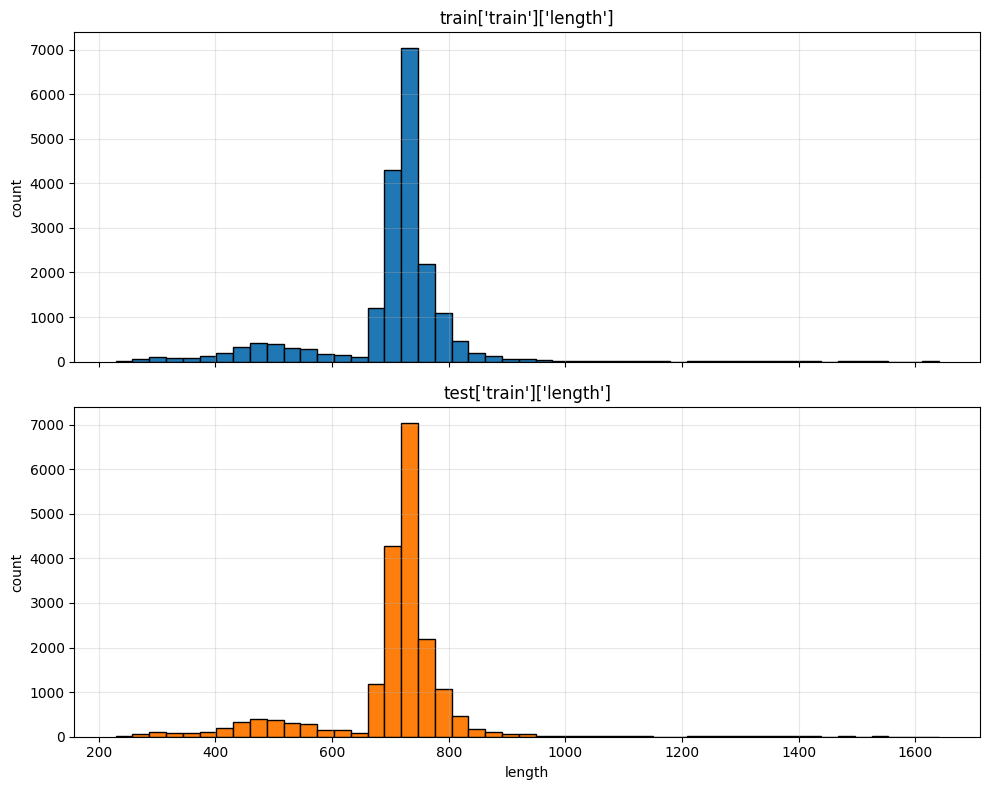

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import datasets

train = datasets.load_dataset('withcomment/path_vqa', split="train")
lengths_train = train['length']   # existing train dataset
lengths_test = train['length']     # existing test dataset

# use common bins for easier comparison
minv = min(min(lengths_train), min(lengths_test))
maxv = max(max(lengths_train), max(lengths_test))
bins = np.linspace(minv, maxv, 50)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
axes[0].hist(lengths_train, bins=bins, color='C0', edgecolor='black')
axes[0].set_ylabel('count')
axes[0].set_title("train['train']['length']")
axes[0].grid(alpha=0.3)

axes[1].hist(lengths_test, bins=bins, color='C1', edgecolor='black')
axes[1].set_xlabel('length')
axes[1].set_ylabel('count')
axes[1].set_title("test['train']['length']")
axes[1].grid(alpha=0.3)

display(max(lengths_train), max(lengths_test))
plt.tight_layout()